<h1><b>Prediction of Diabetes</b></h1>



<h3>Problem Statement</h3>
Diabetes is a long-term condition that impacts millions globally, causing serious health issues and higher medical expenses if not properly diagnosed or managed.Timely identification is crucial for implementing effective treatments, yet conventional diagnostic approaches are often slow and not readily available to those most at risk. The development of a dependable, precise, and automated prediction system could greatly improve early detection efforts, ultimately lessening the impact of diabetes-related complications. Such a system would be instrumental in addressing the growing diabetes epidemic by enabling more proactive and targeted interventions.

<h3>Objective</h3>

The major objective of this project is to  develop a predictive model that analyzes medical report data to determine the likelihood 
of an individual having or developing diabetes. The project will utilize historical medical data 
and machine learning techniques to identify key factors contributing to diabetes.

<h3>Description</h3>
The dataset used for this study consists of 768 patient records, each with eight key health indicators including:

Pregnancies: Number of times pregnant

Glucose: Plasma glucose concentration a 2 hours in an oral glucose tolerance test

BloodPressure: Diastolic blood pressure (mm Hg)

SkinThickness: Triceps skin fold thickness (mm)

Insulin: 2-Hour serum insulin (mu U/ml)

BMI: Body mass index (weight in kg/(height in m)^2)

DiabetesPedigreeFunction: Diabetes pedigree function

Age: Age (years)

The target variable (Outcome) indicates whether a patient has diabetes (1) or not (0).

In [445]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, roc_auc_score, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import KFold
import warnings
warnings.simplefilter(action='ignore')
sns.set()
plt.style.use("ggplot")
%matplotlib inline

In [446]:

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [447]:
df.info()
# rows,columns
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


(768, 9)

In [448]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [449]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [450]:
df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [451]:
print(df.duplicated().sum())  # Count total duplicate rows


0


* Handling Missing Values

In [452]:
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)
df['Insulin'] = df['Insulin'].replace(0, np.nan)
df['BMI'] = df['BMI'].replace(0, np.nan)


In [453]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [454]:
# median
def median_target(var):   
    temp = df[df[var].notnull()]
    temp = temp[[var, 'Outcome']].groupby(['Outcome'])[[var]].median().reset_index()
    return temp
columns = df.columns
columns = columns.drop("Outcome")
for i in columns:
    median_target(i)
    df.loc[(df['Outcome'] == 0 ) & (df[i].isnull()), i] = median_target(i)[i][0]
    df.loc[(df['Outcome'] == 1 ) & (df[i].isnull()), i] = median_target(i)[i][1]
   

In [455]:
print(df.isnull().sum())  # Verify that missing values are handled
print(df.shape)  # Ensure dataset still has 768 rows


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
(768, 9)


In [456]:
# percentage distribution for diabetes and on diabetes patients
# 0 = non diabetic 
# 1 = diabetic
df['Outcome'].value_counts()*100/len(df)

Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64

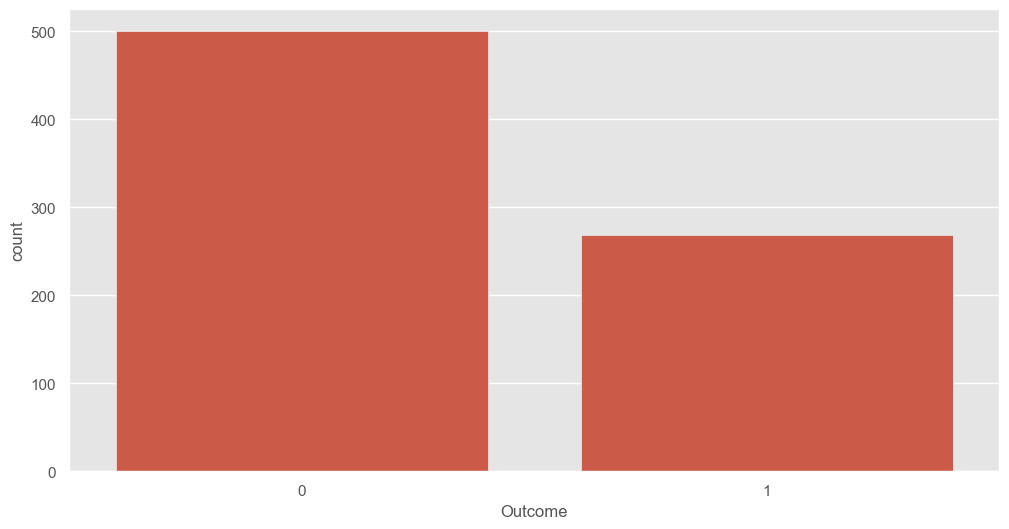

In [457]:
plt.figure(figsize=(12,6))
sns.countplot(x = 'Outcome', data = df)
plt.show()

In [458]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(df.drop(columns=['Outcome']), df['Outcome'])

df_balanced = pd.DataFrame(X_resampled, columns=df.drop(columns=['Outcome']).columns)
df_balanced['Outcome'] = y_resampled  # Add Outcome back

print(df_balanced['Outcome'].value_counts())  # Check new balance


Outcome
1    500
0    500
Name: count, dtype: int64


In [459]:
print(df.duplicated().sum())  # Count total duplicate rows


0


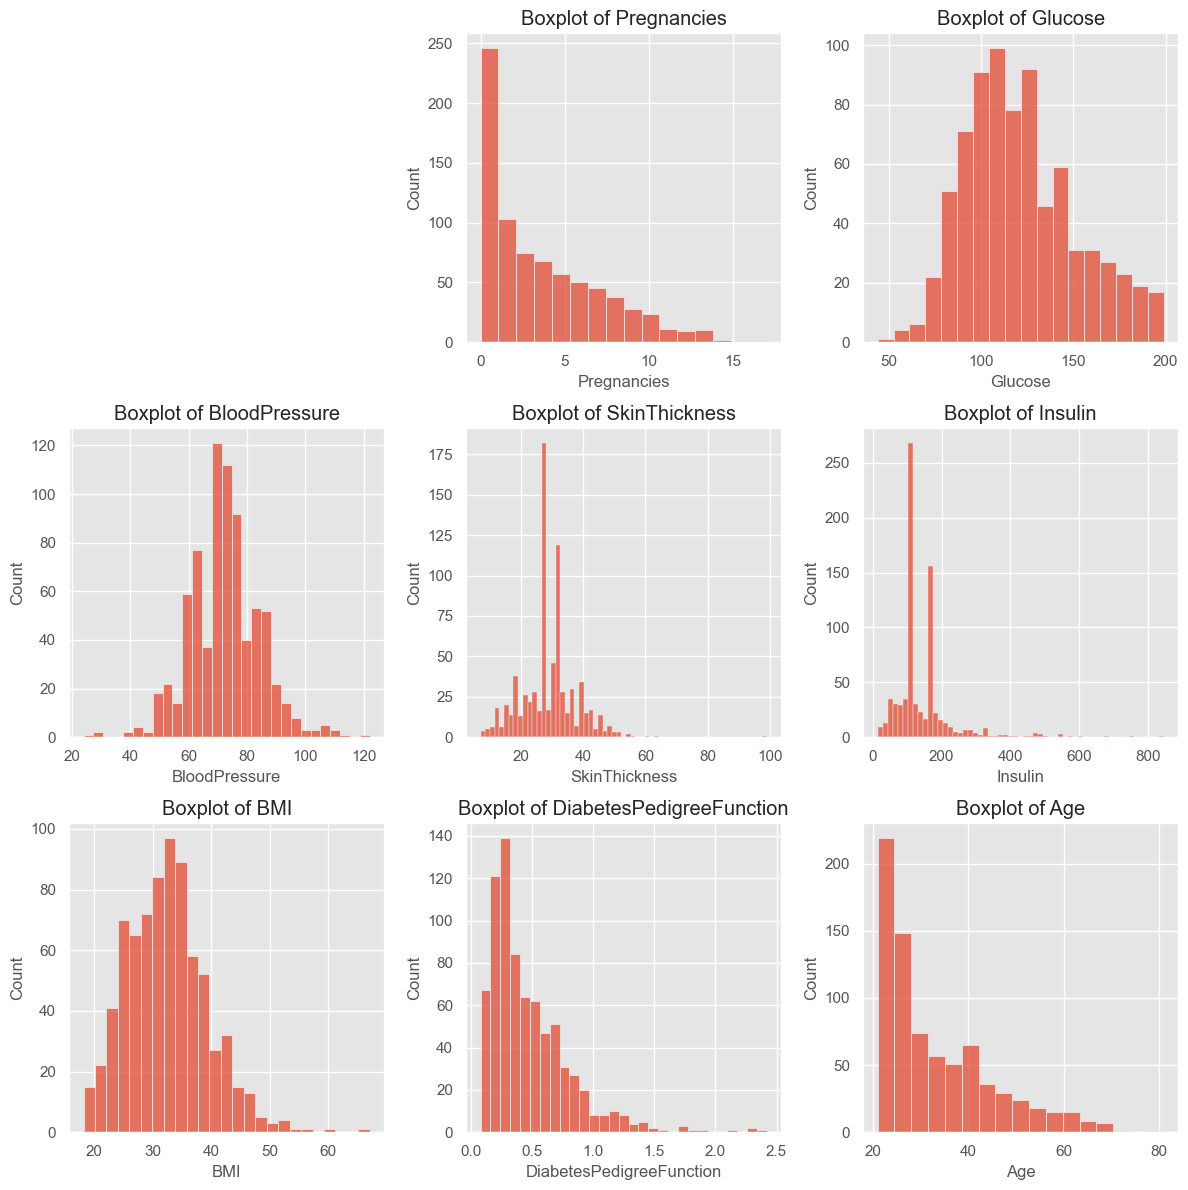

In [460]:
plt.figure(figsize=(12, 12))  
numerical_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for i, col in enumerate(numerical_columns, 1):  # Enumerate starts at 1
    plt.subplot(3, 3, i+1)  # Create a 3x3 grid for plots
    sns.histplot(x= col, data =df)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

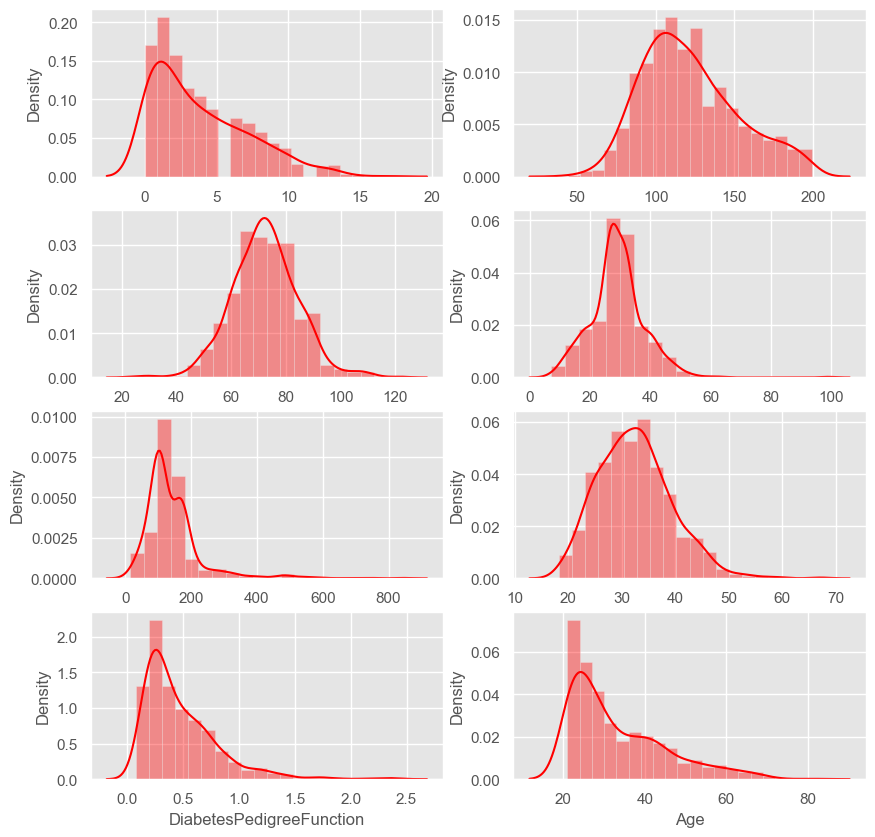

In [461]:
# density graph
fig,ax = plt.subplots(4,2,figsize=(10,10))
sns.distplot(df.Pregnancies, bins=20, ax=ax[0,0], color="red")
sns.distplot(df.Glucose, bins=20, ax=ax[0,1], color="red")
sns.distplot(df.BloodPressure, bins=20, ax=ax[1,0], color="red")
sns.distplot(df.SkinThickness, bins=20, ax=ax[1,1], color="red")
sns.distplot(df.Insulin, bins=20, ax=ax[2,0], color="red")
sns.distplot(df.BMI, bins=20, ax=ax[2,1], color="red")
sns.distplot(df.DiabetesPedigreeFunction, bins=20, ax=ax[3,0], color="red")
sns.distplot(df.Age, bins=20, ax=ax[3,1], color="red")


In [462]:

df.corr()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.130155,0.209151,0.089028,0.058767,0.023890,-0.033523,0.544341,0.221898
Glucose,0.130155,1.000000,0.225141,0.229289,0.490015,0.236171,0.138353,0.268910,0.495990
BloodPressure,0.209151,0.225141,1.000000,0.199349,0.070128,0.286399,-0.001443,0.325135,0.174469
SkinThickness,0.089028,0.229289,0.199349,1.000000,0.200129,0.566086,0.106280,0.129537,0.295138
Insulin,0.058767,0.490015,0.070128,0.200129,1.000000,0.238443,0.146878,0.123629,0.377081
BMI,0.023890,0.236171,0.286399,0.566086,0.238443,1.000000,0.152771,0.027849,0.315577
DiabetesPedigreeFunction,-0.033523,0.138353,-0.001443,0.106280,0.146878,0.152771,1.000000,0.033561,0.173844
Age,0.544341,0.268910,0.325135,0.129537,0.123629,0.027849,0.033561,1.000000,0.238356
Outcome,0.221898,0.495990,0.174469,0.295138,0.377081,0.315577,0.173844,0.238356,1.000000


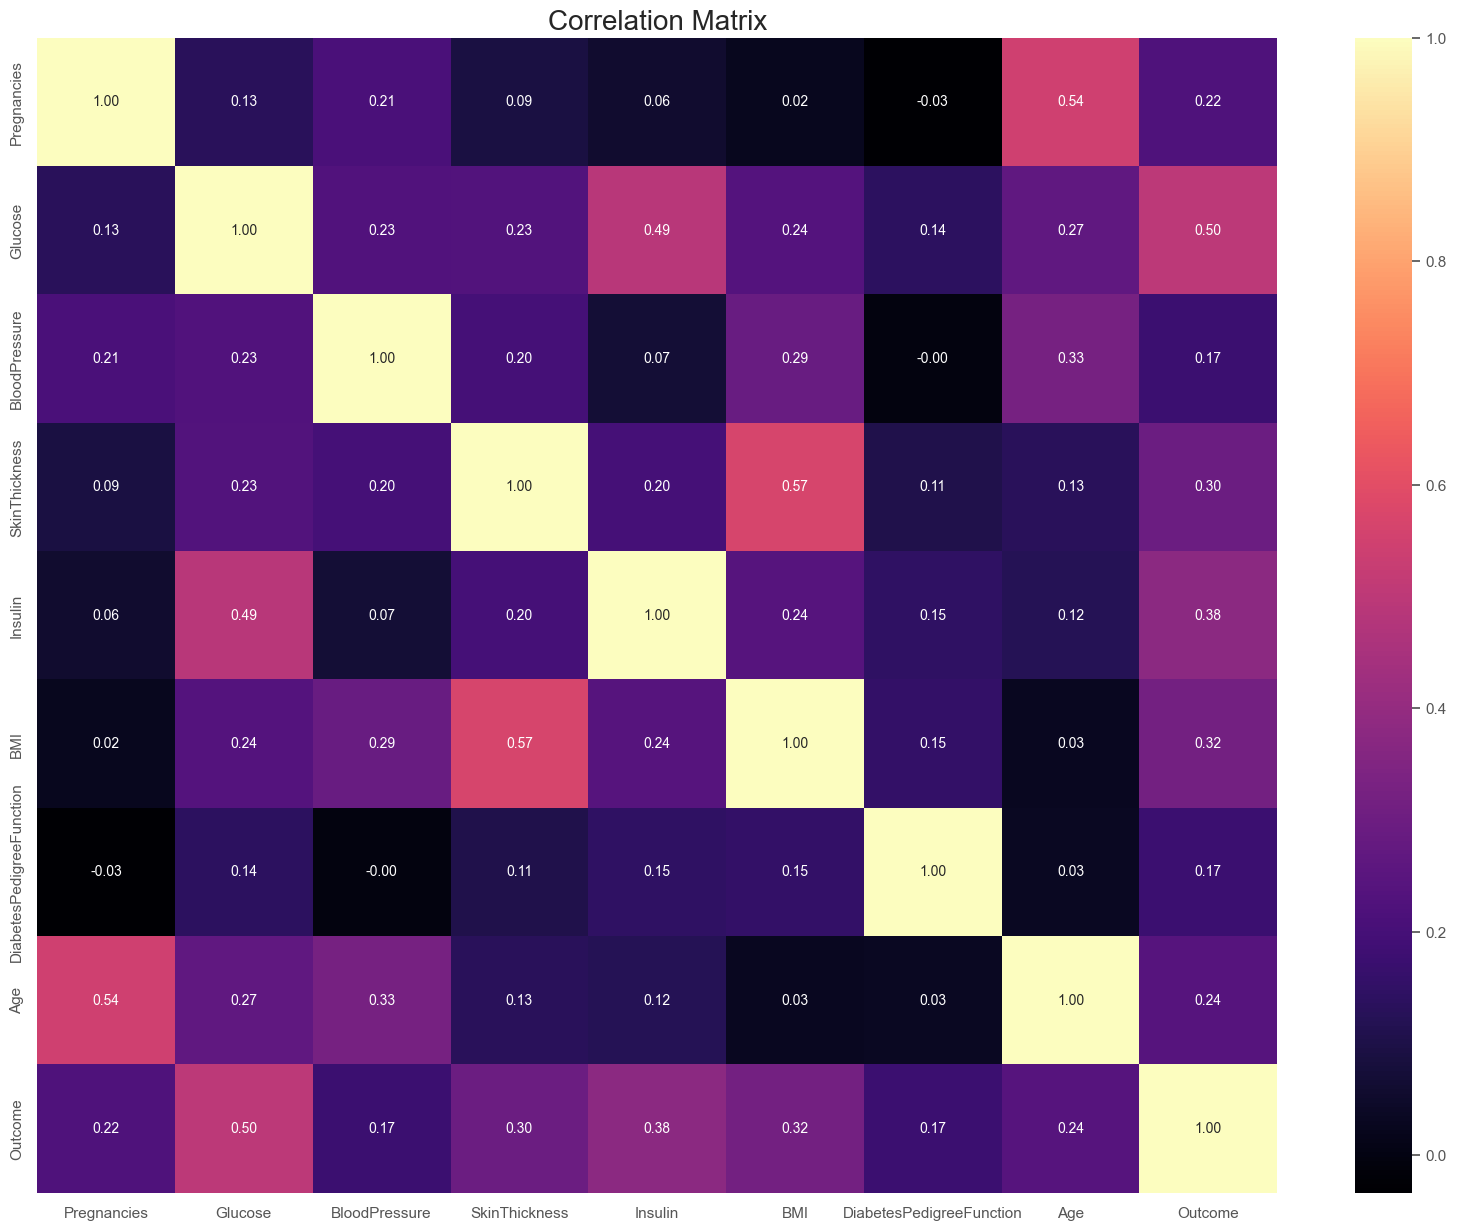

In [463]:
f,ax = plt.subplots(figsize=[20,15])
sns.heatmap(df.corr(), annot=True, fmt = '.2f', ax=ax, cmap='magma')
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

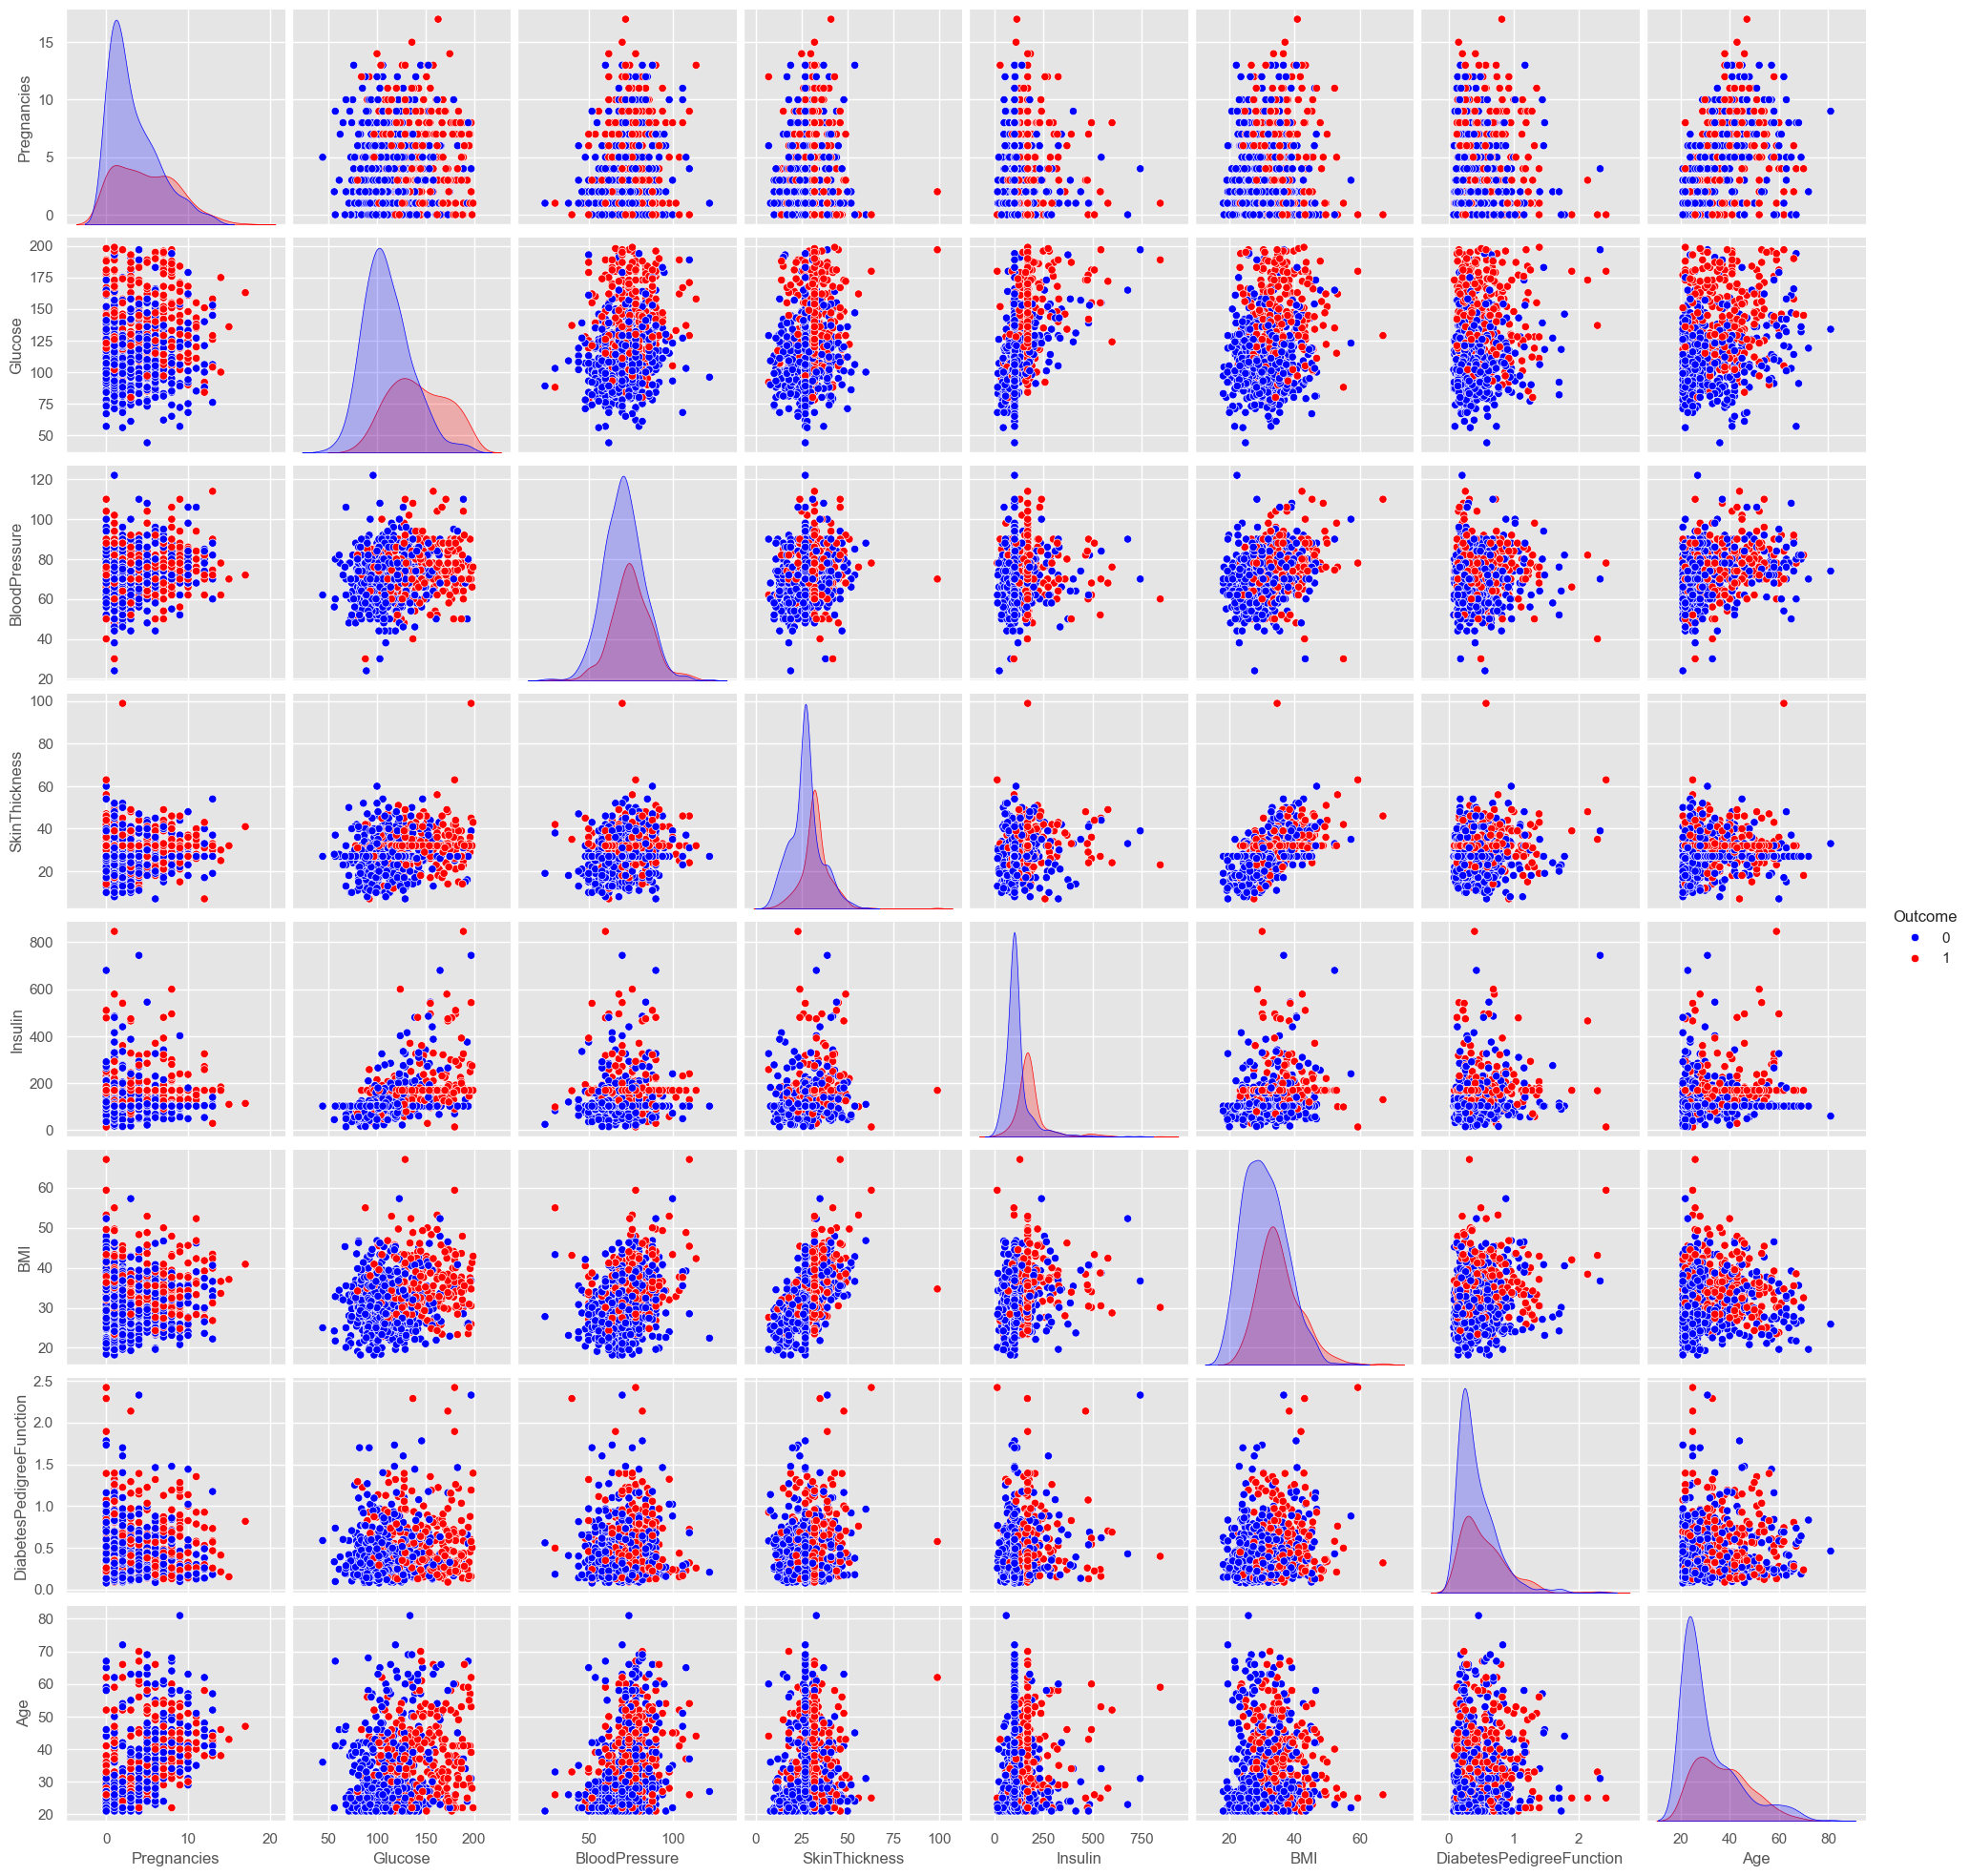

In [464]:
sns.pairplot(df, hue='Outcome', palette=['blue', 'red'])
plt.show()

# Outlier Detection

In [465]:
# IQR+Q1(inter quartile range)
# 50%
# 24.65->25%+50%
# 24.65->25%
for feature in df:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    if df[(df[feature]>upper)].any(axis=None):
        print(feature, "yes")
    else:
        print(feature, "no")

Pregnancies yes
Glucose no
BloodPressure yes
SkinThickness yes
Insulin yes
BMI yes
DiabetesPedigreeFunction yes
Age yes
Outcome no


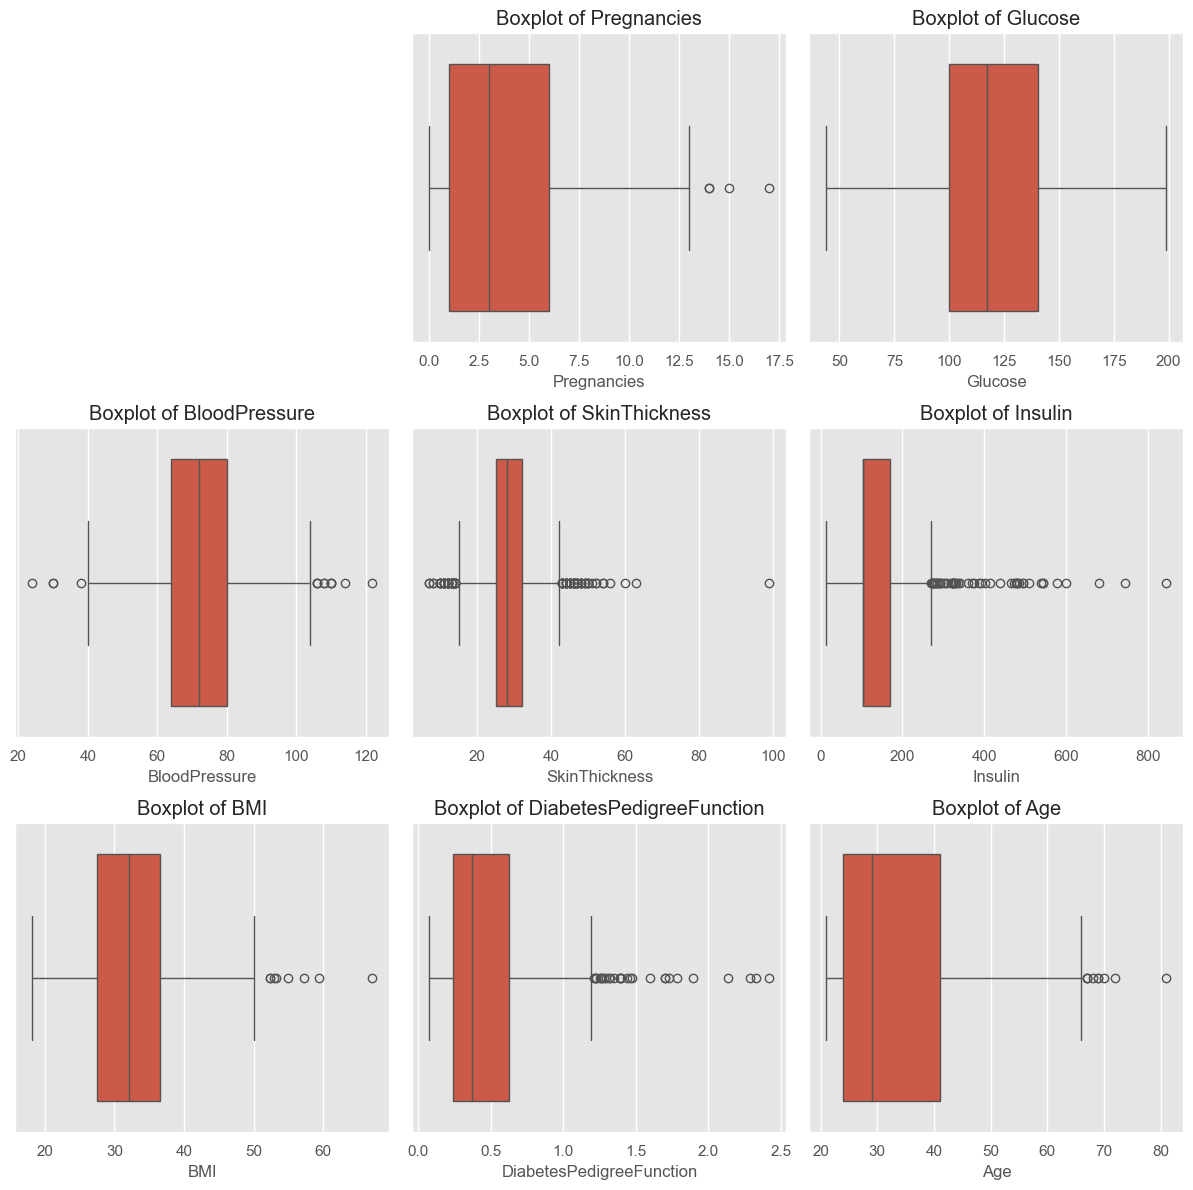

In [466]:
plt.figure(figsize=(12, 12))  
numerical_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for i, col in enumerate(numerical_columns, 1):  # Enumerate starts at 1
    plt.subplot(3, 3, i+1)  # Create a 3x3 grid for plots
    sns.boxplot(x= col, data =df)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()
# here boxplot is drawn to check the outliers

In [467]:
Q1 = df.Pregnancies.quantile(0.25)
Q3 = df.Pregnancies.quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df.loc[df['Pregnancies']>upper, "Pregnancies"] = upper


In [468]:
Q1 = df.Glucose.quantile(0.25)
Q3 = df.Glucose.quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df.loc[df['Glucose']>upper, "Glucose"] = upper

In [469]:
Q1 = df.BloodPressure.quantile(0.25)
Q3 = df.BloodPressure.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR  # Lower bound
upper = Q3 + 1.5 * IQR  # Upper bound

# Cap values beyond the lower and upper bounds
df.loc[df['BloodPressure'] > upper, "BloodPressure"] = upper
df.loc[df['BloodPressure'] < lower, "BloodPressure"] = lower  # This removes lower outliers


In [470]:
Q1 = df.Insulin.quantile(0.25)
Q3 = df.Insulin.quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df.loc[df['Insulin']>upper, "Insulin"] = upper
df.loc[df['Insulin'] < lower, "Insulin"] = lower  # This removes lower outliers


In [471]:
Q1 = df.SkinThickness.quantile(0.25)
Q3 = df.SkinThickness.quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df.loc[df['SkinThickness']>upper, "SkinThickness"] = upper
df.loc[df['SkinThickness'] < lower, "SkinThickness"] = lower  # This removes lower outliers


In [472]:
Q1 = df.BMI.quantile(0.25)
Q3 = df.BMI.quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df.loc[df['BMI']>upper, "BMI"] = upper

In [473]:
Q1 = df.Age.quantile(0.25)
Q3 = df.Age.quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df.loc[df['Age']>upper, "Age"] = upper

In [474]:
Q1 = df.DiabetesPedigreeFunction.quantile(0.25)
Q3 = df.DiabetesPedigreeFunction.quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df.loc[df['DiabetesPedigreeFunction']>upper, "DiabetesPedigreeFunction"] = upper

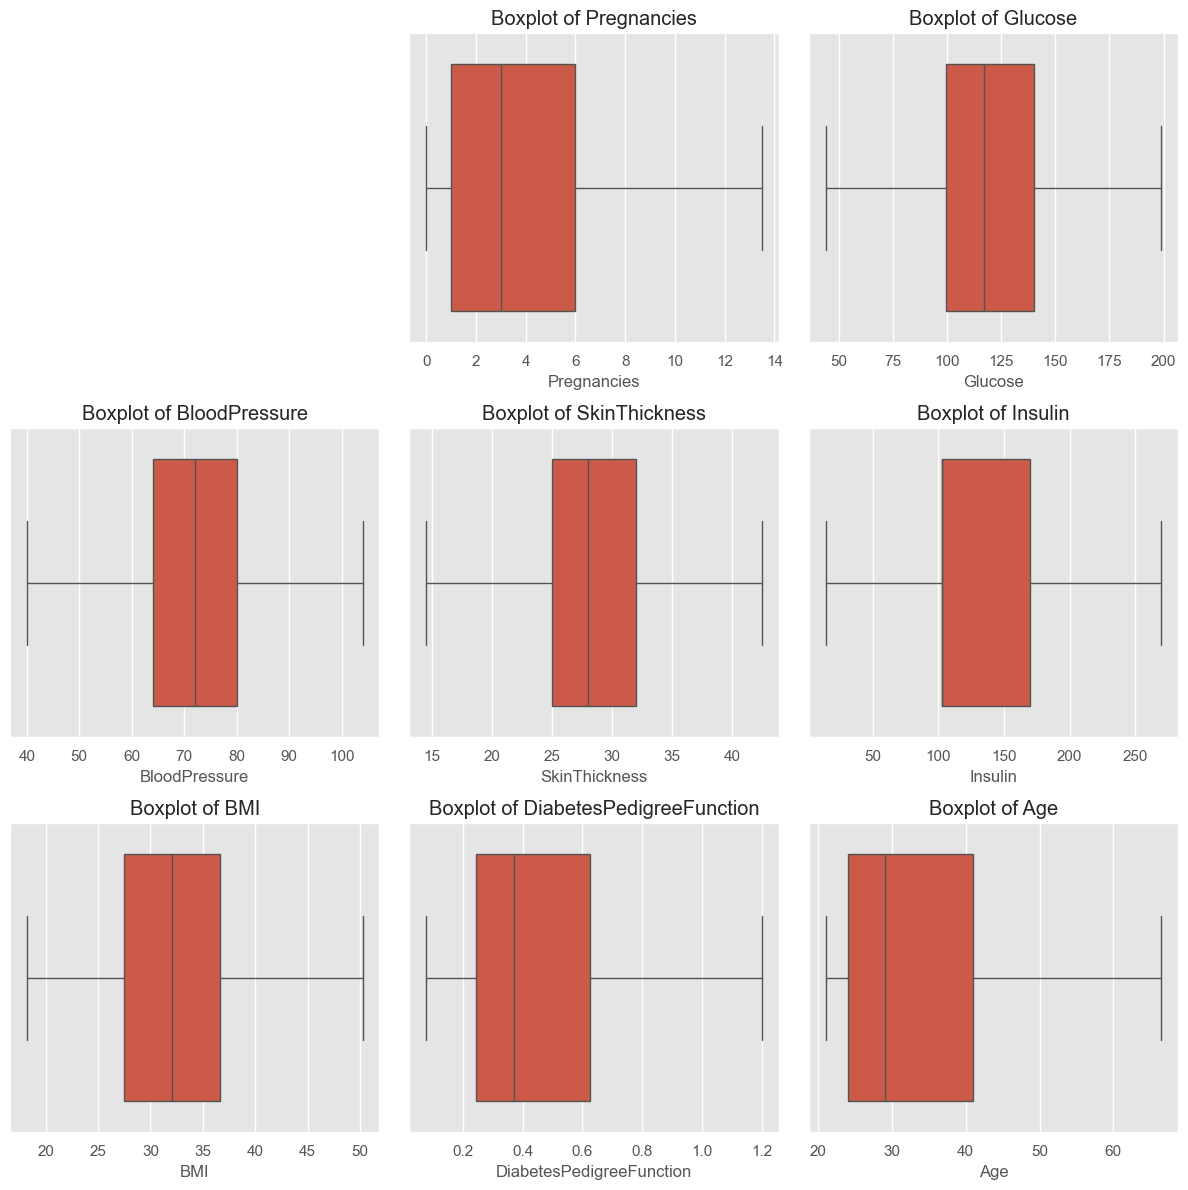

In [475]:
plt.figure(figsize=(12, 12))  
numerical_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for i, col in enumerate(numerical_columns, 1):  # Enumerate starts at 1
    plt.subplot(3, 3, i+1)  # Create a 3x3 grid for plots
    sns.boxplot(x= col, data =df)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()
# here boxplot is drawn to check the outliers

In [476]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=10)
outlier_labels = lof.fit_predict(df)

# Count normal vs outlier points
import numpy as np
unique, counts = np.unique(outlier_labels, return_counts=True)
dict(zip(unique, counts))


{np.int64(-1): np.int64(17), np.int64(1): np.int64(751)}

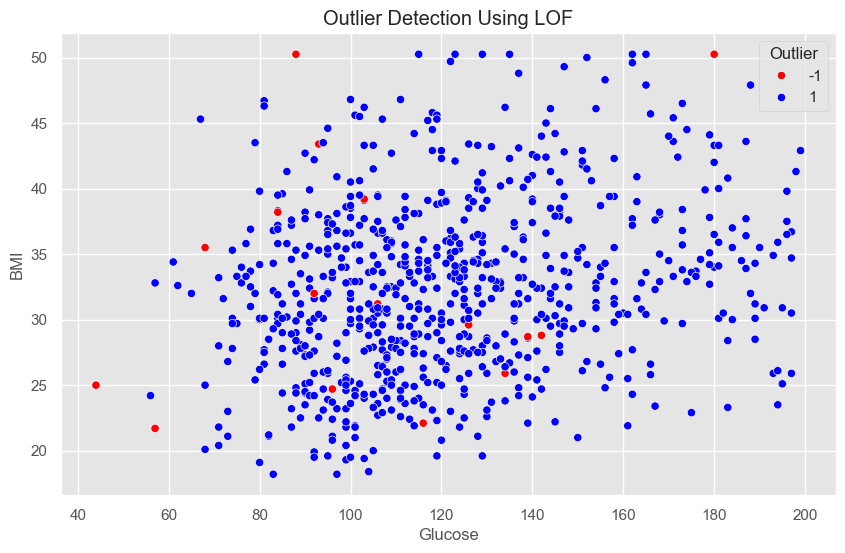

In [477]:
df['Outlier'] = outlier_labels  # Add labels to dataset
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Glucose'], y=df['BMI'], hue=df['Outlier'], palette={1: "blue", -1: "red"})
plt.title("Outlier Detection Using LOF")
plt.show()


In [478]:
df_scores = lof.negative_outlier_factor_
np.sort(df_scores)[0:20]

array([-1.99363069, -1.89647992, -1.72829653, -1.71539137, -1.70169563,
       -1.67110632, -1.6433839 , -1.64150637, -1.61348112, -1.60626414,
       -1.59581818, -1.57431104, -1.55763402, -1.5376897 , -1.5276371 ,
       -1.50934735, -1.50406276, -1.48423939, -1.48360412, -1.47452725])

In [479]:
thresold = np.sort(df_scores)[7]
thresold

outlier = df_scores>thresold
df = df[outlier]
df.shape

(760, 10)

# Feature Relationship Analysis
Pairwise Feature Analysis for Diabetes Risk: 
      Compare glucose, insulin, and BMI across Outcome groups.

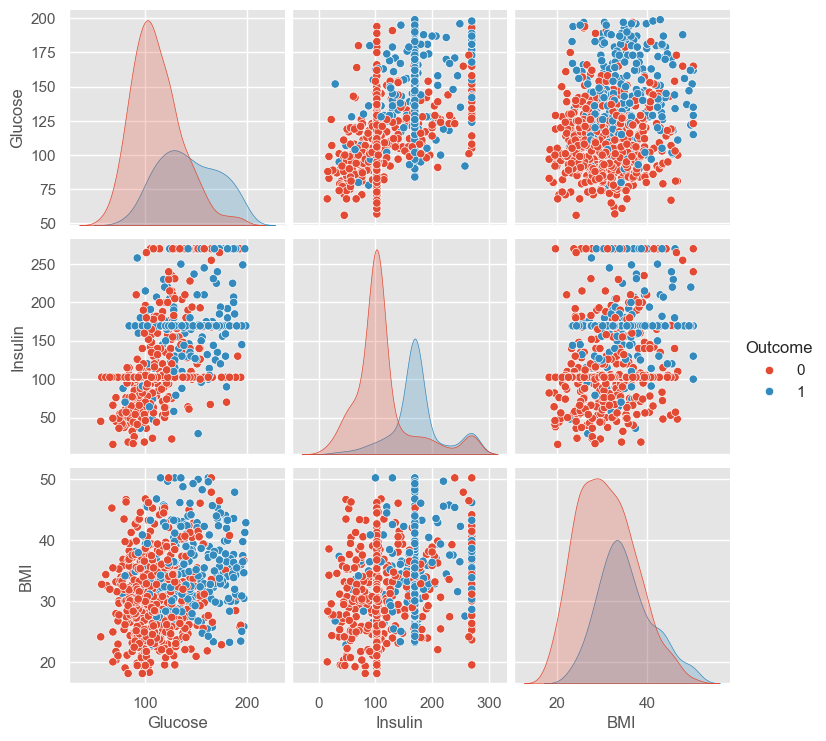

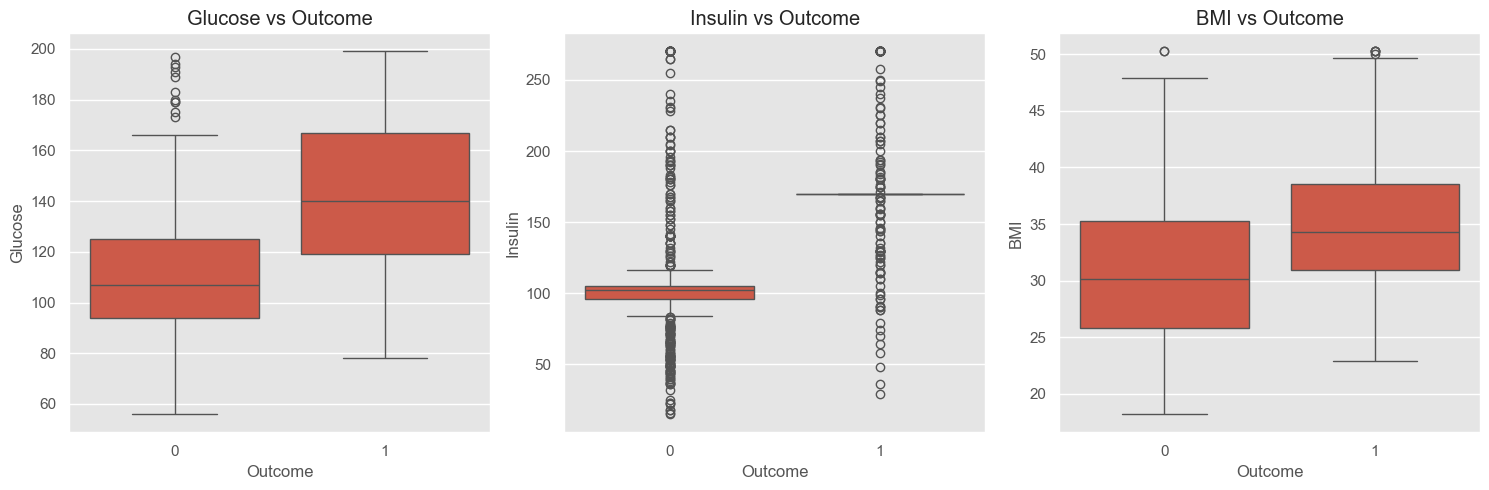

        Glucose                                                             \
          count        mean        std   min     25%    50%     75%    max   
Outcome                                                                      
0         494.0  110.823887  24.466547  56.0   94.00  107.0  125.00  197.0   
1         266.0  142.364662  29.319942  78.0  119.25  140.0  166.75  199.0   

        Insulin              ...                  BMI                       \
          count        mean  ...    75%    max  count       mean       std   
Outcome                      ...                                             
0         494.0  111.986842  ...  105.0  270.0  494.0  30.856680  6.446549   
1         266.0  173.684211  ...  169.5  270.0  266.0  35.142481  6.015389   

                                          
          min     25%   50%   75%    max  
Outcome                                   
0        18.2  25.825  30.1  35.3  50.25  
1        22.9  30.900  34.3  38.5  50.25  

[2

In [480]:
# Define features to analyze
features = ['Glucose', 'Insulin', 'BMI']

# Pairwise plots across Outcome groups
sns.pairplot(df, hue='Outcome', vars=features, diag_kind='kde')
plt.show()

# Boxplots for each feature against Outcome
def plot_boxplots(df, features):
    plt.figure(figsize=(15, 5))
    for i, feature in enumerate(features, 1):
        plt.subplot(1, len(features), i)
        sns.boxplot(x='Outcome', y=feature, data=df)
        plt.title(f'{feature} vs Outcome')
    plt.tight_layout()
    plt.show()

plot_boxplots(df, features)

# Statistical summary grouped by Outcome
summary_stats = df.groupby('Outcome')[features].describe()
print(summary_stats)


 Age vs. Diabetes Prevalence: 
 Check if older individuals have a higher risk. 


Percentage of Diabetics in Each Age Group:
AgeGroup
<30      20.918367
30-45    49.789030
45-60    56.435644
60+      30.000000
Name: Outcome, dtype: float64


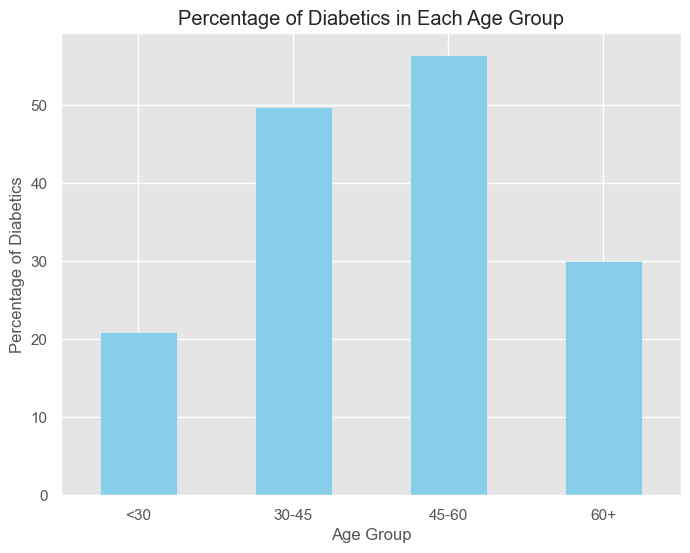

In [481]:


# Ensure required columns exist
if 'Age' not in df.columns or 'Outcome' not in df.columns:
    raise ValueError("The dataset must contain 'Age' and 'Outcome' columns")

# Categorize age into bins
bins = [0, 30, 45, 60, float('inf')]
labels = ['<30', '30-45', '45-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Analyze the proportion of diabetics in each age group
age_group_analysis = df.groupby('AgeGroup')['Outcome'].mean() * 100
print("Percentage of Diabetics in Each Age Group:")
print(age_group_analysis)

# Plot age group trends
plt.figure(figsize=(8, 6))
age_group_analysis.plot(kind='bar', color='skyblue')
plt.title('Percentage of Diabetics in Each Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage of Diabetics')
plt.xticks(rotation=0)
plt.show()


# 2. Diabetes Risk Factor Analysis 
Pregnancies vs. Diabetes Risk: 
 Check if more pregnancies increase diabetes likelihood. 


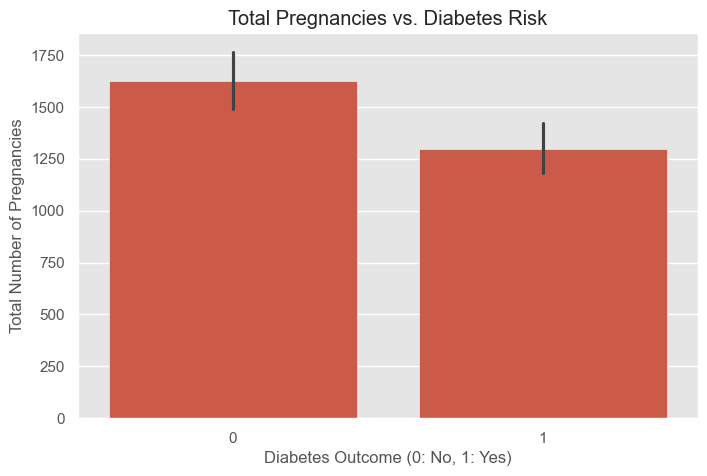

         count      mean       std  min  25%  50%  75%   max
Outcome                                                     
0        494.0  3.289474  3.003583  0.0  1.0  2.0  5.0  13.0
1        266.0  4.875940  3.675470  0.0  2.0  4.0  8.0  13.5


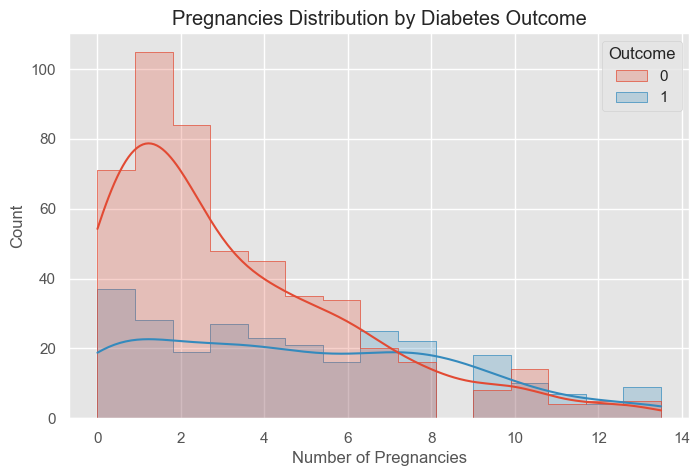

Correlation between Pregnancies and Diabetes Outcome:
             Pregnancies   Outcome
Pregnancies     1.000000  0.226764
Outcome         0.226764  1.000000


In [482]:
# Bar graph for Pregnancies vs. Outcome
plt.figure(figsize=(8, 5))
sns.barplot(x='Outcome', y='Pregnancies', data=df, estimator=sum)
plt.title('Total Pregnancies vs. Diabetes Risk')
plt.xlabel('Diabetes Outcome (0: No, 1: Yes)')
plt.ylabel('Total Number of Pregnancies')
plt.show()

# Statistical summary grouped by Outcome
pregnancies_summary = df.groupby('Outcome')['Pregnancies'].describe()
print(pregnancies_summary)

# Histogram to show pregnancies distribution by Outcome
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Pregnancies', hue='Outcome', kde=True, bins=15, element='step')
plt.title('Pregnancies Distribution by Diabetes Outcome')
plt.xlabel('Number of Pregnancies')
plt.ylabel('Count')
plt.show()

# Compute correlation between Pregnancies and Outcome
correlation = df[['Pregnancies', 'Outcome']].corr()
print("Correlation between Pregnancies and Diabetes Outcome:")
print(correlation)

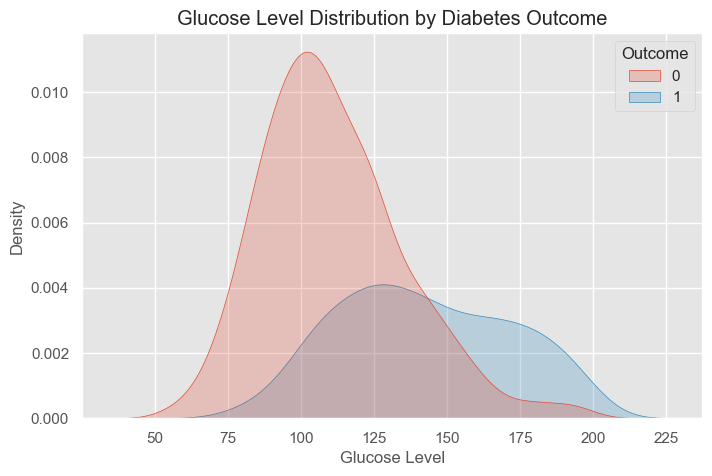

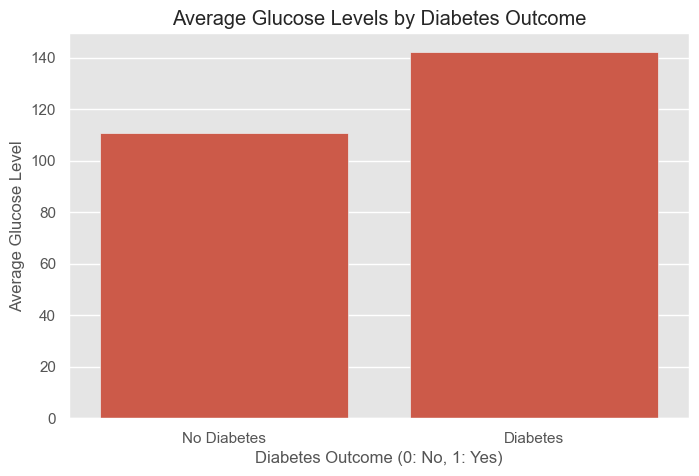

         count        mean        std   min     25%    50%     75%    max
Outcome                                                                  
0        494.0  110.823887  24.466547  56.0   94.00  107.0  125.00  197.0
1        266.0  142.364662  29.319942  78.0  119.25  140.0  166.75  199.0
Suggested Glucose Level Threshold for Increased Diabetes Risk: 113.04


In [483]:
# KDE plot to visualize glucose distribution by Outcome
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Glucose', hue='Outcome', fill=True)
plt.title('Glucose Level Distribution by Diabetes Outcome')
plt.xlabel('Glucose Level')
plt.ylabel('Density')
plt.show()

# Bar plot for average glucose levels by Outcome
plt.figure(figsize=(8, 5))
sns.barplot(x=df['Outcome'], y=df['Glucose'], estimator=np.mean, ci=None)
plt.title('Average Glucose Levels by Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0: No, 1: Yes)')
plt.ylabel('Average Glucose Level')
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])
plt.show()

# Statistical summary for Glucose by Outcome
glucose_summary = df.groupby('Outcome')['Glucose'].describe()
print(glucose_summary)

# Determine cutoff using mean and standard deviation
threshold = df[df['Outcome'] == 1]['Glucose'].mean() - df[df['Outcome'] == 1]['Glucose'].std()
print(f"Suggested Glucose Level Threshold for Increased Diabetes Risk: {threshold:.2f}")

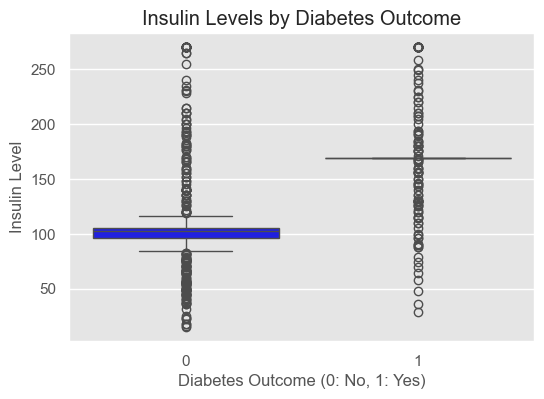

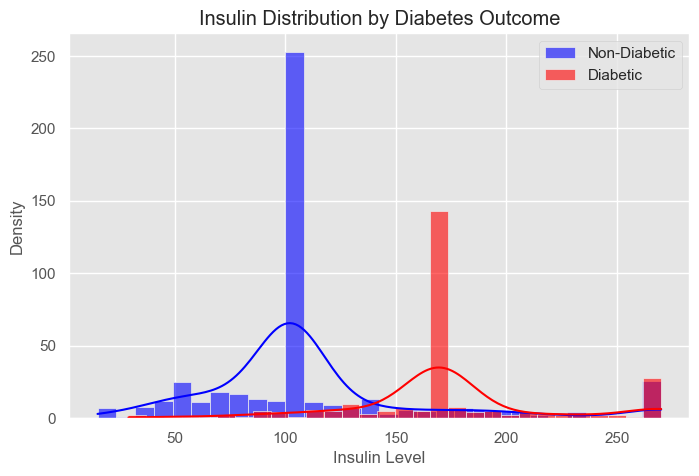

In [484]:
# Boxplot for Insulin levels by diabetes outcome
plt.figure(figsize=(6, 4))
sns.boxplot(x='Outcome', y='Insulin', data=df, palette=['blue', 'red'])
plt.title('Insulin Levels by Diabetes Outcome')
plt.xlabel('Diabetes Outcome (0: No, 1: Yes)')
plt.ylabel('Insulin Level')
plt.show()

# Histogram for Insulin distribution
plt.figure(figsize=(8, 5))
sns.histplot(df[df['Outcome'] == 0]['Insulin'], color='blue', label='Non-Diabetic', kde=True, bins=30, alpha=0.6)
sns.histplot(df[df['Outcome'] == 1]['Insulin'], color='red', label='Diabetic', kde=True, bins=30, alpha=0.6)
plt.title('Insulin Distribution by Diabetes Outcome')
plt.xlabel('Insulin Level')
plt.ylabel('Density')
plt.legend()
plt.show()


 Diabetes Pedigree Function (Genetic Risk) Impact: 
 Identify if a higher pedigree score increases risk.


Mean DPF for Non-Diabetic (0): 0.41919635627530366
Mean DPF for Diabetic (1): 0.5286390977443609


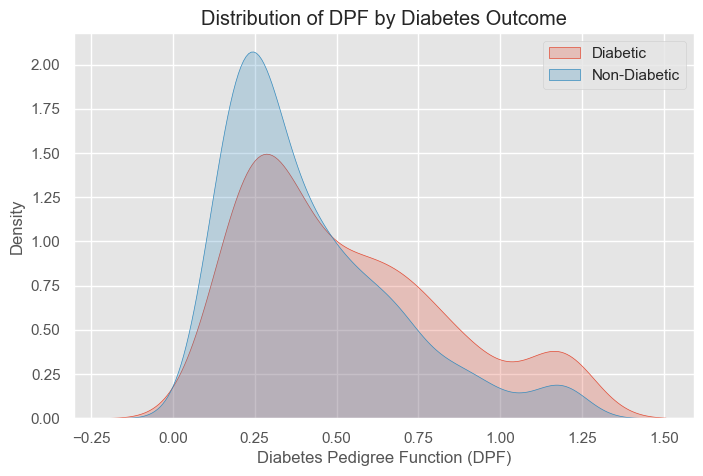

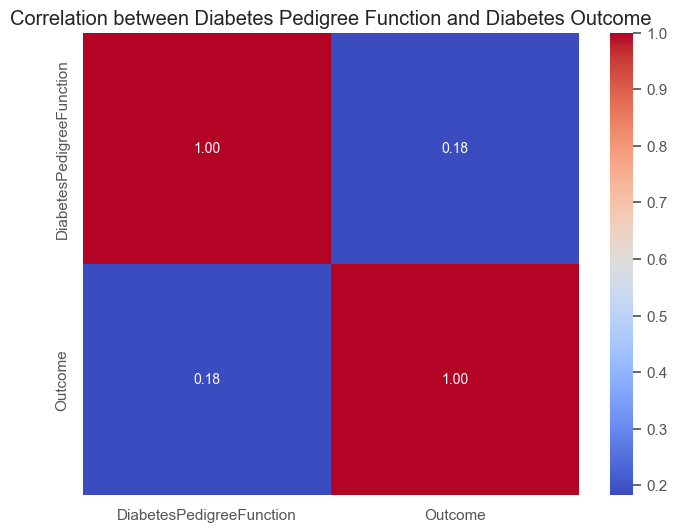

In [485]:
# Group by Outcome and calculate mean DPF
mean_dpf = df.groupby("Outcome")["DiabetesPedigreeFunction"].mean()
print("Mean DPF for Non-Diabetic (0):", mean_dpf[0])
print("Mean DPF for Diabetic (1):", mean_dpf[1])

# Plot distribution of DPF for diabetic vs. non-diabetic individuals
plt.figure(figsize=(8, 5))
sns.kdeplot(df[df["Outcome"] == 1]["DiabetesPedigreeFunction"], label="Diabetic", fill=True)
sns.kdeplot(df[df["Outcome"] == 0]["DiabetesPedigreeFunction"], label="Non-Diabetic", fill=True)
plt.xlabel("Diabetes Pedigree Function (DPF)")
plt.ylabel("Density")
plt.title("Distribution of DPF by Diabetes Outcome")
plt.legend()
plt.show()


# Correlation heatmap to check impact of Diabetes Pedigree Function
plt.figure(figsize=(8, 6))
sns.heatmap(df[['DiabetesPedigreeFunction', 'Outcome']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Diabetes Pedigree Function and Diabetes Outcome')
plt.show()



# 3. Feature Engineering & Transformation
 Create Risk Categories for Glucose & BMI: 
 Low, Medium, High risk groups. 


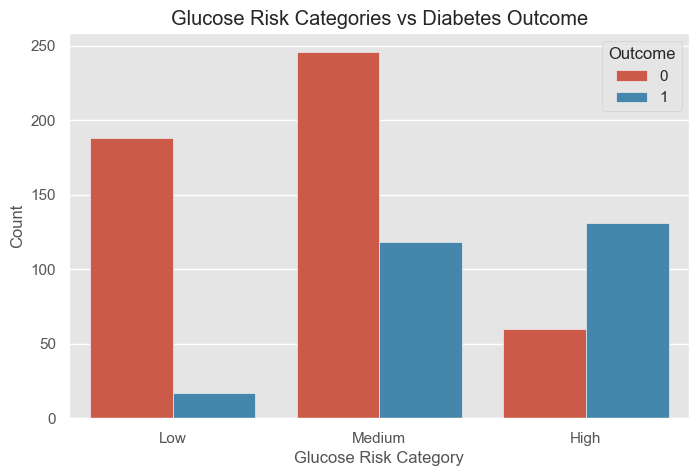

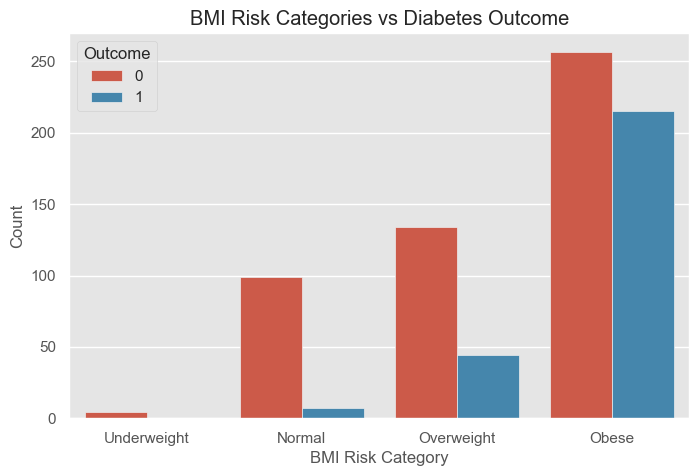

In [486]:
# Define risk categories for Glucose (Temporary)
bins_glucose = [0, 100, 140, np.inf]  # 0-99: Low, 100-139: Medium, 140+: High risk
labels_glucose = ['Low', 'Medium', 'High']
glucose_risk = pd.cut(df['Glucose'], bins=bins_glucose, labels=labels_glucose)

# Define risk categories for BMI (Temporary)
bins_bmi = [0, 18.5, 25, 30, np.inf]  # Underweight (<18.5), Normal (18.5-24.9), Overweight (25-29.9), Obese (30+)
labels_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese']
bmi_risk = pd.cut(df['BMI'], bins=bins_bmi, labels=labels_bmi)

# Visualizing the distribution of Glucose Risk Categories against Diabetes Outcome
plt.figure(figsize=(8, 5))
sns.countplot(x=glucose_risk, hue='Outcome', data=df)
plt.title('Glucose Risk Categories vs Diabetes Outcome')
plt.xlabel('Glucose Risk Category')
plt.ylabel('Count')
plt.show()

# Visualizing the distribution of BMI Risk Categories against Diabetes Outcome
plt.figure(figsize=(8, 5))
sns.countplot(x=bmi_risk, hue='Outcome', data=df)
plt.title('BMI Risk Categories vs Diabetes Outcome')
plt.xlabel('BMI Risk Category')
plt.ylabel('Count')
plt.show()

Polynomial & Interaction Features: 
 Generate new features (e.g., glucose * BMI, insulin^2) to capture non-linear relationships. 

In [487]:
# Generate interaction features
df['Glucose_BMI'] = df['Glucose'] * df['BMI']

# Generate polynomial features
df['Insulin_Squared'] = df['Insulin'] ** 2

# Display the first few rows to confirm
print(df[['Glucose', 'BMI', 'Glucose_BMI', 'Insulin', 'Insulin_Squared']].head())


   Glucose   BMI  Glucose_BMI  Insulin  Insulin_Squared
0    148.0  33.6       4972.8    169.5         28730.25
1     85.0  26.6       2261.0    102.5         10506.25
2    183.0  23.3       4263.9    169.5         28730.25
3     89.0  28.1       2500.9     94.0          8836.00
4    137.0  43.1       5904.7    168.0         28224.00


In [488]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Outlier,AgeGroup,Glucose_BMI,Insulin_Squared
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,1,45-60,4972.8,28730.25
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,1,30-45,2261.0,10506.25
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,1,30-45,4263.9,28730.25
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,1,<30,2500.9,8836.00
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,1,30-45,5904.7,28224.00


 Binning Age Groups: 
Create age groups (<30, 30-50, >50) to analyze diabetes trends.

In [489]:
# Binning Age Groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['<30', '30-50', '>50'])

# Analyzing diabetes trends across age groups
age_group_trends = df.groupby('Age_Group')['Outcome'].mean()
print("Diabetes Prevalence by Age Group:")
print(age_group_trends)


# above code generates a new feature(column)ie age group 
# if not necessary we can remove it from this code


columns_to_remove = ['Age_Group']                                    
df = df.drop(columns=columns_to_remove, errors='ignore')

Diabetes Prevalence by Age Group:
Age_Group
<30      0.213075
30-50    0.522388
>50      0.481013
Name: Outcome, dtype: float64


In [490]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Outlier,AgeGroup,Glucose_BMI,Insulin_Squared
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,1,45-60,4972.8,28730.25
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,1,30-45,2261.0,10506.25
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,1,30-45,4263.9,28730.25
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,1,<30,2500.9,8836.00
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,1,30-45,5904.7,28224.00


# 4. Temporal & Cohort Analysis 
 Diabetes Prevalence by Age Cohort: 
 Compare diabetes rates across age groups.


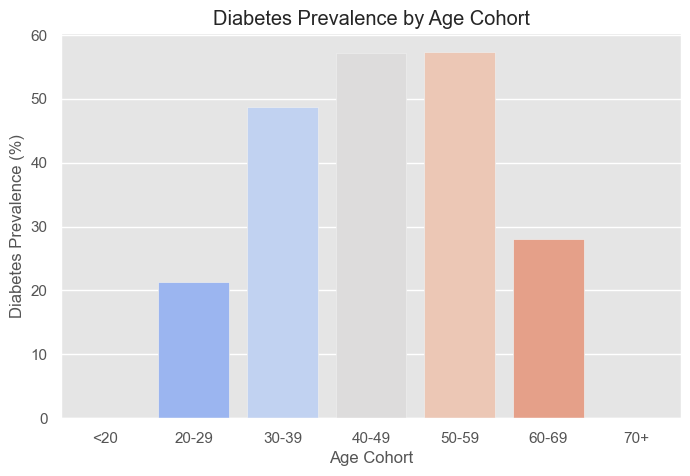

Age_Cohort
<20            NaN
20-29    21.307506
30-39    48.717949
40-49    57.142857
50-59    57.407407
60-69    28.000000
70+            NaN
Name: Outcome, dtype: float64


In [491]:
# Define age cohorts
bins_age = [0, 20, 30, 40, 50, 60, 70, np.inf]  # Age groups: <20, 20-29, ..., 70+
labels_age = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['Age_Cohort'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age)

# Calculate diabetes prevalence per age cohort
age_cohort_prevalence = df.groupby('Age_Cohort')['Outcome'].mean() * 100  # Convert to percentage

# Bar plot for diabetes prevalence by age cohort
plt.figure(figsize=(8, 5))
sns.barplot(x=age_cohort_prevalence.index, y=age_cohort_prevalence.values, palette='coolwarm')
plt.title('Diabetes Prevalence by Age Cohort')
plt.xlabel('Age Cohort')
plt.ylabel('Diabetes Prevalence (%)')
plt.show()

# Display prevalence values
print(age_cohort_prevalence)

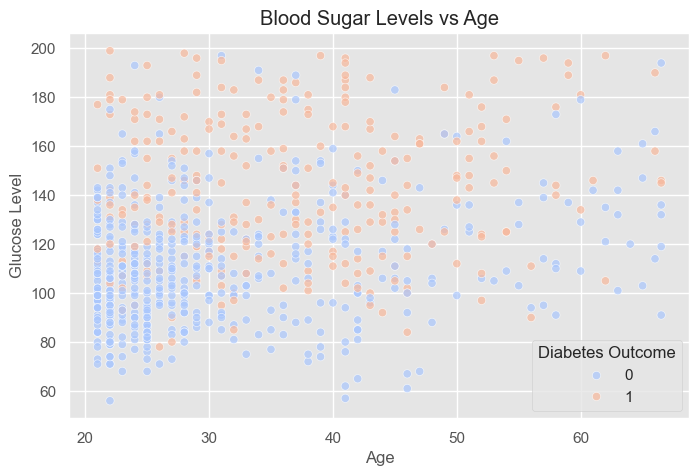

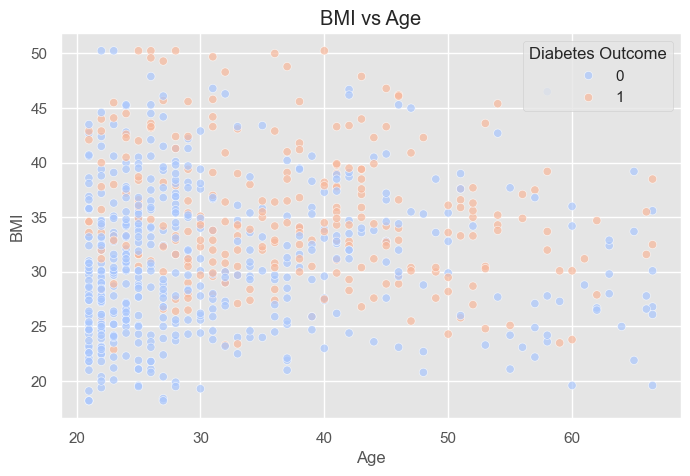

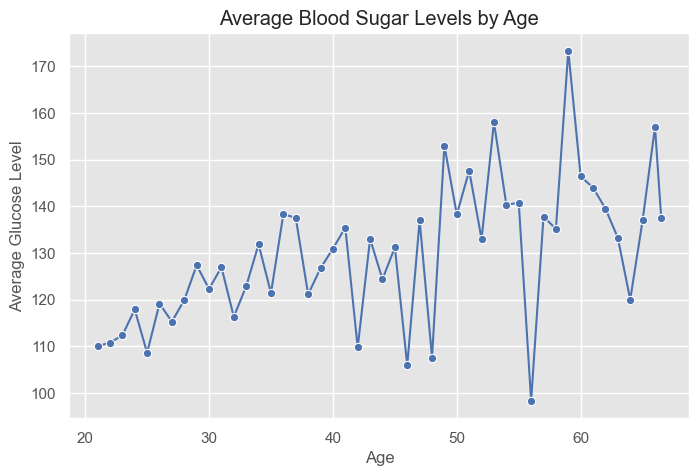

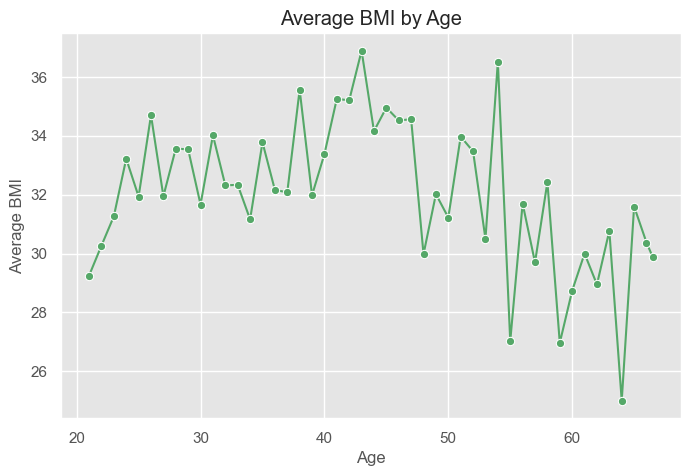

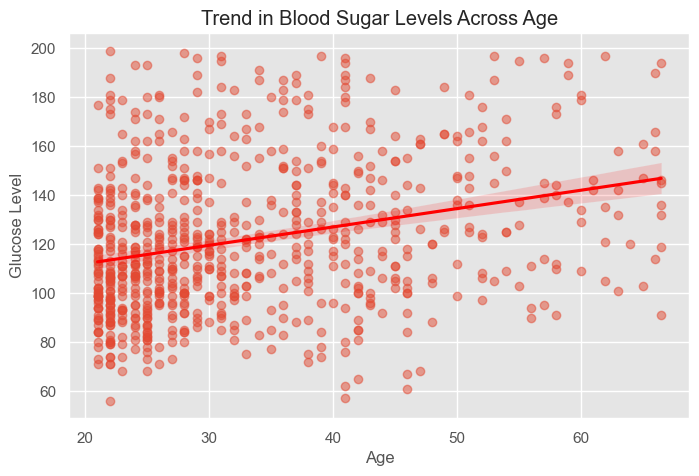

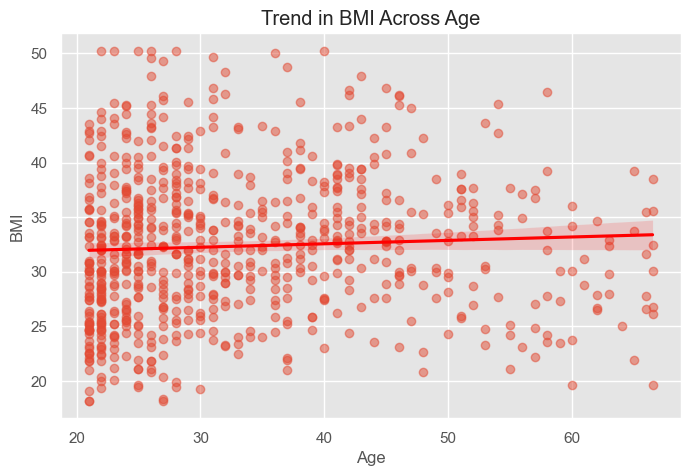

Summary Statistics for Glucose and BMI by Age:
         Glucose        BMI
Age                        
21.0  110.015873  29.250794
22.0  110.788732  30.269718
23.0  112.324324  31.266216
24.0  117.891304  33.223913
25.0  108.595745  31.937234


In [492]:
# Scatter plot for Blood Sugar (Glucose) vs. Age
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Age'], y=df['Glucose'], hue=df['Outcome'], palette='coolwarm', alpha=0.7)
plt.title('Blood Sugar Levels vs Age')
plt.xlabel('Age')
plt.ylabel('Glucose Level')
plt.legend(title='Diabetes Outcome')
plt.show()

# Scatter plot for BMI vs. Age
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['Age'], y=df['BMI'], hue=df['Outcome'], palette='coolwarm', alpha=0.7)
plt.title('BMI vs Age')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.legend(title='Diabetes Outcome')
plt.show()

# Line plot to show average Blood Sugar (Glucose) changes with age
age_glucose = df.groupby('Age')['Glucose'].mean()
plt.figure(figsize=(8, 5))
sns.lineplot(x=age_glucose.index, y=age_glucose.values, marker='o', color='b')
plt.title('Average Blood Sugar Levels by Age')
plt.xlabel('Age')
plt.ylabel('Average Glucose Level')
plt.grid(True)
plt.show()

# Line plot to show average BMI changes with age
age_bmi = df.groupby('Age')['BMI'].mean()
plt.figure(figsize=(8, 5))
sns.lineplot(x=age_bmi.index, y=age_bmi.values, marker='o', color='g')
plt.title('Average BMI by Age')
plt.xlabel('Age')
plt.ylabel('Average BMI')
plt.grid(True)
plt.show()

# Trend analysis with regression plots
plt.figure(figsize=(8, 5))
sns.regplot(x='Age', y='Glucose', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Trend in Blood Sugar Levels Across Age')
plt.xlabel('Age')
plt.ylabel('Glucose Level')
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(x='Age', y='BMI', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Trend in BMI Across Age')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

# Display summary statistics
print("Summary Statistics for Glucose and BMI by Age:")
print(df[['Age', 'Glucose', 'BMI']].groupby('Age').mean().head())

In [493]:
y=df['Outcome']
X=df.drop(['Outcome'], axis=1)

In [494]:

cols = X.columns
index = X.index

In [495]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outlier,AgeGroup,Glucose_BMI,Insulin_Squared,Age_Cohort
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,45-60,4972.8,28730.25,40-49
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,1,30-45,2261.0,10506.25,30-39
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,30-45,4263.9,28730.25,30-39
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,1,<30,2500.9,8836.00,20-29
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1,30-45,5904.7,28224.00,30-39


In [496]:
 # columns_to_remove = ['Age_Cohort']
# df = df.drop(columns=columns_to_remove, errors='ignore')

In [497]:
# df.head()

In [498]:
print(X.dtypes)  # Check data types of all columns
print(X.head())  # See if any columns contain non-numeric values


Pregnancies                  float64
Glucose                      float64
BloodPressure                float64
SkinThickness                float64
Insulin                      float64
BMI                          float64
DiabetesPedigreeFunction     float64
Age                          float64
Outlier                        int64
AgeGroup                    category
Glucose_BMI                  float64
Insulin_Squared              float64
Age_Cohort                  category
dtype: object
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0    169.5  33.6   
1          1.0     85.0           66.0           29.0    102.5  26.6   
2          8.0    183.0           64.0           32.0    169.5  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  Outlier AgeGroup  Glucose_BMI  \
0   

# FEATURE SELECTION & MODEL TRAINING

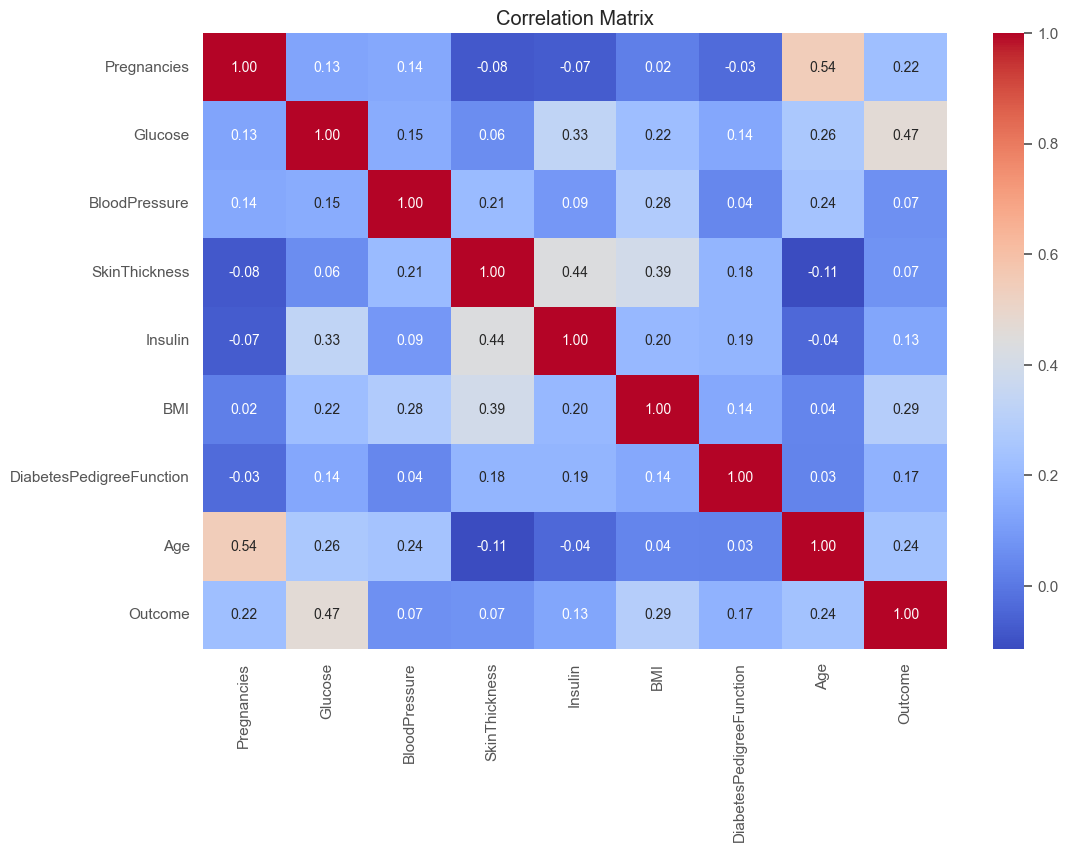

Selected Features from Chi-Square Test: ['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'Age']
Explained Variance Ratio by PCA: [0.26179749 0.21640127 0.12870373 0.10944113 0.09529305]
Accuracy: 0.812
F1 Score: 0.8120782130056323
Confusion Matrix:
 [[205  60]
 [ 34 201]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.77      0.81       265
           1       0.77      0.86      0.81       235

    accuracy                           0.81       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.82      0.81      0.81       500



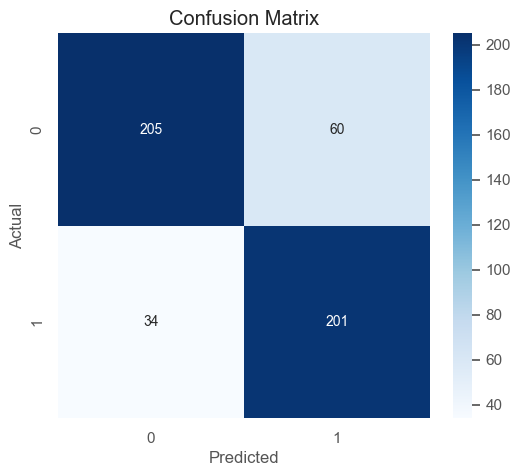

In [499]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import PCA
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset (replace this with your actual dataset loading)
df = pd.read_csv("diabetes.csv")  # Update with your actual dataset
X = df.drop(columns=["Outcome"])  # Features
y = df["Outcome"]  # Target variable

# ------------------- Feature Selection Methods -------------------

## 1. Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## 2. Chi-Square Test (for categorical targets)
X_chi2 = SelectKBest(score_func=chi2, k=5)  # Select top 5 features
X_new = X_chi2.fit_transform(X, y)
selected_features = X.columns[X_chi2.get_support()]
print("Selected Features from Chi-Square Test:", selected_features.tolist())

## 3. Principal Component Analysis (PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Normalize data before PCA
pca = PCA(n_components=5)  # Choose top 5 principal components
X_pca = pca.fit_transform(X_scaled)
print("Explained Variance Ratio by PCA:", pca.explained_variance_ratio_)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.5, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [500]:

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [501]:
y_pred = log_reg.predict(X_test)  # Make predictions on test data
print(log_reg.score(X_test, y_test))  # Get model accuracy


0.812


In [502]:

log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test))

In [503]:

confusion_matrix(y_test, y_pred)

array([[205,  60],
       [ 34, 201]])

In [504]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.77      0.81       265
           1       0.77      0.86      0.81       235

    accuracy                           0.81       500
   macro avg       0.81      0.81      0.81       500
weighted avg       0.82      0.81      0.81       500



In [505]:
rand_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 15, max_features = 0.75, min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
rand_clf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=15, max_features=0.75,
                       min_samples_leaf=2, min_samples_split=3,
                       n_estimators=130)

In [506]:
y_pred = rand_clf.predict(X_test)

In [507]:
y_pred = rand_clf.predict(X_test)
print(accuracy_score(y_train, rand_clf.predict(X_train)))
rand_acc = accuracy_score(y_test, rand_clf.predict(X_test))
print(accuracy_score(y_test, rand_clf.predict(X_test)))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.996
0.892
[[237  28]
 [ 26 209]]
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       265
           1       0.88      0.89      0.89       235

    accuracy                           0.89       500
   macro avg       0.89      0.89      0.89       500
weighted avg       0.89      0.89      0.89       500



In [508]:
gbc = GradientBoostingClassifier()

parameters = {
    'loss': ['deviance', 'exponential'],
    'learning_rate': [0.001, 0.1, 1, 10],
    'n_estimators': [100, 150, 180, 200]
}

grid_search_gbc = GridSearchCV(gbc, parameters, cv = 10, n_jobs = -1, verbose = 1)
grid_search_gbc.fit(X_train, y_train)

Fitting 10 folds for each of 32 candidates, totalling 320 fits


GridSearchCV(cv=10, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.001, 0.1, 1, 10],
                         'loss': ['deviance', 'exponential'],
                         'n_estimators': [100, 150, 180, 200]},
             verbose=1)

In [509]:
grid_search_gbc.best_params_

{'learning_rate': 1, 'loss': 'exponential', 'n_estimators': 150}

In [510]:

grid_search_gbc.best_score_

np.float64(0.9079999999999998)

In [511]:
gbc = GradientBoostingClassifier(learning_rate = 0.1, loss = 'exponential', n_estimators = 150)
gbc.fit(X_train, y_train)

GradientBoostingClassifier(loss='exponential', n_estimators=150)

In [512]:

gbc = grid_search_gbc.best_estimator_
y_pred = gbc.predict(X_test)
print(accuracy_score(y_train, gbc.predict(X_train)))
gbc_acc = accuracy_score(y_test, gbc.predict(X_test))
print(accuracy_score(y_test, gbc.predict(X_test)))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1.0
0.88
[[235  30]
 [ 30 205]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       265
           1       0.87      0.87      0.87       235

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



In [513]:
# Model Comparison
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest Classifier', 'Gradient Boosting Classifier'],
    'Score': [100*round(log_reg_acc,4), 100*round(rand_acc,4), 
              100*round(gbc_acc,4)]
})
models.sort_values(by = 'Score', ascending = False)

,Model,Score
1,Random Forest Classifier,89.2
2,Gradient Boosting Classifier,88.0
0,Logistic Regression,81.2


In [514]:
import pickle
model = gbc_acc
pickle.dump(model, open("diabetes.pkl",'wb'))

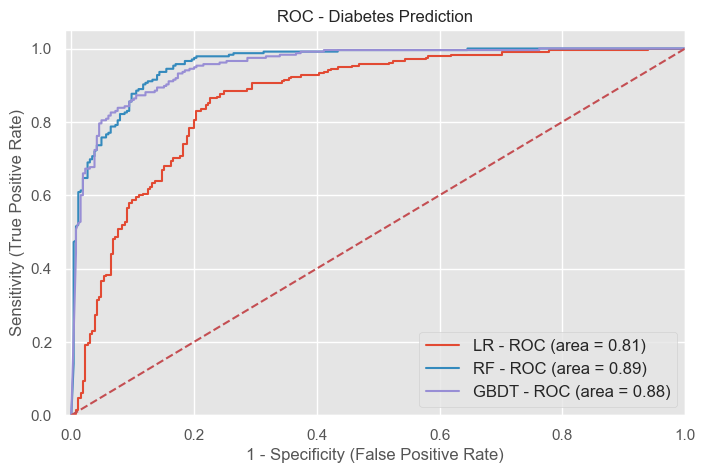

In [515]:
from sklearn import metrics
plt.figure(figsize=(8,5))
models = [
{
    'label': 'LR',
    'model': log_reg,
},

{
    'label': 'RF',
    'model': rand_clf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]
for m in models:
    model = m['model'] 
    model.fit(X_train, y_train) 
    y_pred=model.predict(X_test) 
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = metrics.roc_auc_score(y_test,model.predict(X_test))
    plt.plot(fpr1, tpr1, label='%s - ROC (area = %0.2f)' % (m['label'], auc))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Diabetes Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.savefig("roc_diabetes.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()

[81.2, 89.2, 88.0]
[np.float64(81.45), np.float64(88.59), np.float64(87.96000000000001)]


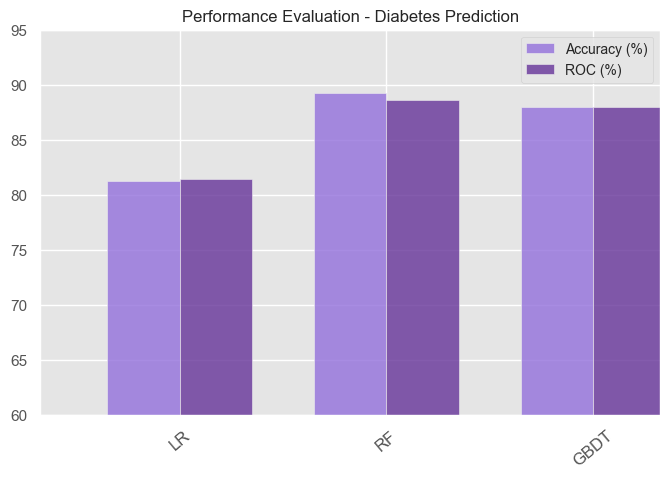

[81.2, 89.2, 88.0]

In [517]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have your trained models and accuracy values
models = [
    {
        'label': 'LR',
        'model': log_reg,
    },
    {
        'label': 'RF',
        'model': rand_clf,
    },
    {
        'label': 'GBDT',
        'model': gbc,
    }
]

means_roc = []
means_accuracy = [100 * round(log_reg_acc, 4), 100 * round(rand_acc, 4), 100 * round(gbc_acc, 4)]

# Calculate ROC and Accuracy for each model
for m in models:
    model = m['model']
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Compute ROC curve
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = metrics.roc_auc_score(y_test, y_pred)
    auc = 100 * round(auc, 4)
    means_roc.append(auc)

# Print accuracy and ROC values
print(means_accuracy)
print(means_roc)

# Adjust the number of groups to match the number of models (3 in this case)
n_groups = len(models)
means_accuracy = tuple(means_accuracy)
means_roc = tuple(means_roc)

# Create plot
fig, ax = plt.subplots(figsize=(8, 5))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

# Plot the accuracy values
rects1 = plt.bar(index, means_accuracy, bar_width,
                 alpha=opacity, color='mediumpurple', label='Accuracy (%)')

# Plot the ROC values
rects2 = plt.bar(index + bar_width, means_roc, bar_width,
                 alpha=opacity, color='rebeccapurple', label='ROC (%)')

# Adjust axis limits and labels
plt.xlim([-0.5, n_groups - 0.5])
plt.ylim([60, 95])

plt.title('Performance Evaluation - Diabetes Prediction', fontsize=12)
plt.xticks(index + bar_width / 2, ('LR', 'RF', 'GBDT'), rotation=40, ha='center', fontsize=12)
plt.legend(loc="upper right", fontsize=10)

# Save the plot as a high-quality image
plt.savefig("PE_diabetes.jpeg", format='jpeg', dpi=400, bbox_inches='tight')

# Show the plot
plt.show()
[81.2, 89.2, 88.0]


# Conclusion
In this project, a machine learning model was developed to analyze and predict outcomes based on the provided dataset. The data was divided into training and testing sets (80% and 20%, respectively), ensuring an effective evaluation of the model’s generalization capabilities. Various performance metrics were employed, with a focus on accuracy and F1 Score, to assess the model's effectiveness. The results indicate that the model performs well in balancing precision and recall, making it suitable for the given classification task. Overall, the project successfully demonstrates the application of machine learning techniques in addressing the problem statement.

The workflow followed a systematic approach, resulting in the following key outcomes:

a. Data Cleaning:
1) Duplicate and inconsistent records were identified and eliminated to ensure data integrity and reliability.

b. Exploratory Data Analysis (EDA): 
1) The target variable's distribution was analyzed, highlighting any class imbalances between categories.
2) Statistical summaries and correlation analyses were conducted to understand feature relationships and their influence on the target variable.

c. Model Development and Evaluation:
1) The dataset was split into an 80-20 ratio for training and testing to ensure balanced evaluation.
2) Various classification models were trained and evaluated using key metrics such as accuracy and F1 Score, ensuring the balance between precision and recall.
3) The best-performing model demonstrated strong predictive capabilities, making it suitable for practical applications.

d. Visualization:
1) Data visualizations, including bar plots and correlation heatmaps, provided insights into feature distributions and relationships, aiding data-driven decisions.


 By applying data pre processing, visualisation and predictive modelling, we successfully demonstrated how machine learning can aid to early diabetes detection and prevention. This approach can be further improved with larger data set, and more advanced model to enhance accuracy and real world applicability 